# Кейс 7 — Когортный анализ LTV: качество трафика во времени

**Контекст:** Media buying / iGaming аналитика  
**Период данных:** Q1–Q2 2024  
**Инструменты:** Python (pandas, matplotlib)  
**Датасеты:** `cohort_metrics.csv` + `player_deposits.csv` + `players.csv`

---

## Постановка задачи

Когортный анализ — это взгляд на трафик через время.  
Один и тот же источник может давать разный «урожай» в разные месяцы.

**Ключевые вопросы:**
1. Как меняется LTV игроков по когортам — стабильно или есть тренды?
2. Какие источники удерживают игроков лучше всего (Retention D30/D90)?
3. Когда окупается CAC — Payback Period по источникам?
4. Какие когорты стоит масштабировать, а какие сигнализируют о проблемах?
5. Как выглядит простой прогноз LTV за пределами наблюдаемых 90 дней?

---

### Что такое когорта в iGaming

**Когорта** — группа игроков, сделавших первый депозит (FTD) в одном и том же месяце.

```
Когорта январь 2024 = все игроки с FTD в январе 2024
  → Смотрим, сколько из них вернулись через 7 / 30 / 90 дней
  → Считаем, сколько NGR они принесли за каждый период
  → Сравниваем с другими когортами
```

### Ключевые метрики

| Метрика | Формула | Что показывает |
|---|---|---|
| **LTV 30d** | NGR за 30 дней / n_players | Ценность игрока за первый месяц |
| **LTV 90d** | NGR за 90 дней / n_players | Ценность за квартал |
| **Retention D30** | вернувшихся на D30 / FTD × 100% | Удержание через месяц |
| **Payback** | CAC / (LTV_30d / 30) | Дней до окупаемости |

---


## 0. Импорт и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.facecolor': '#F8F9FA', 'axes.facecolor': '#F8F9FA'})

COLORS = {
    'Google_Search': '#4285F4', 'Facebook':      '#1877F2',
    'Native_Ads':    '#FF9500', 'Push_Network':  '#E53935',
    'TikTok':        '#69C9D0', 'Affiliate_SEO': '#34A853',
}
SRC_ORDER = ['Affiliate_SEO','Google_Search','Facebook','Native_Ads','TikTok','Push_Network']
MONTHS    = ['2024-01','2024-02','2024-03','2024-04','2024-05','2024-06']


In [2]:
coh = pd.read_csv('../data/cohort_metrics.csv')
dep = pd.read_csv('../data/player_deposits.csv', parse_dates=['deposit_date'])
pl  = pd.read_csv('../data/players.csv',         parse_dates=['ftd_date', 'reg_date'])

coh6 = coh[coh['cohort_month'].isin(MONTHS)].copy()

print(f"cohort_metrics: {coh.shape} — {coh['cohort_month'].nunique()} когорт")
print(f"player_deposits: {dep.shape}")
print(f"players: {pl.shape} — fraud: {pl['is_fraud'].sum():,} ({pl['is_fraud'].mean():.1%})")
print(f"\nКогорты в анализе: {MONTHS}")
print(f"Источники: {sorted(coh6['source'].unique())}")


cohort_metrics: (42, 15) — 7 когорт
player_deposits: (26168, 8)
players: (15000, 10) — fraud: 379 (2.5%)

Когорты в анализе: ['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06']
Источники: ['Affiliate_SEO', 'Facebook', 'Google_Search', 'Native_Ads', 'Push_Network', 'TikTok']


## 1. Когортные матрицы

In [3]:
# Retention D30 matrix
ret_matrix = coh6.pivot_table(
    index='cohort_month', columns='source',
    values='retention_d30_pct', aggfunc='mean'
)
ret_matrix = ret_matrix[[c for c in SRC_ORDER if c in ret_matrix.columns]].round(1)

print("=== Retention D30 % (строки = когорта, столбцы = источник) ===")
print("Читай: какой % игроков вернулся на 30-й день после FTD")
ret_matrix


=== Retention D30 % (строки = когорта, столбцы = источник) ===
Читай: какой % игроков вернулся на 30-й день после FTD


source,Affiliate_SEO,Google_Search,Facebook,Native_Ads,TikTok,Push_Network
cohort_month,,,,,,
2024-01,47.8,45.6,33.9,29.1,20.7,7.1
2024-02,53.6,46.7,41.9,26.1,25.7,14.3
2024-03,51.2,46.5,36.6,26.0,13.6,15.9
2024-04,50.7,46.5,36.0,27.2,21.0,12.5
2024-05,50.2,44.6,35.2,29.2,23.2,14.5
2024-06,41.0,36.0,26.9,21.3,14.8,13.6


In [4]:
# LTV 90d matrix
ltv_matrix = coh6.pivot_table(
    index='cohort_month', columns='source',
    values='ltv_90d', aggfunc='mean'
)
ltv_matrix = ltv_matrix[[c for c in SRC_ORDER if c in ltv_matrix.columns]].round(2)

print("=== LTV 90d ($ per player) по когортам ===")
ltv_matrix


=== LTV 90d ($ per player) по когортам ===


source,Affiliate_SEO,Google_Search,Facebook,Native_Ads,TikTok,Push_Network
cohort_month,,,,,,
2024-01,7.57,5.05,4.12,4.10,2.98,2.90
2024-02,7.65,5.24,4.48,3.91,3.52,3.51
2024-03,7.55,5.04,4.41,3.78,3.04,3.26
2024-04,7.88,5.07,4.32,3.81,3.82,2.70
2024-05,7.57,4.56,4.29,3.90,3.78,3.41
2024-06,6.13,4.09,3.77,3.37,3.09,3.17


## 2. Retention по источникам (D1 / D7 / D30 / D90)

In [5]:
ret_src = coh6.groupby('source').agg(
    D1  = ('retention_d1_pct',  'mean'),
    D7  = ('retention_d7_pct',  'mean'),
    D30 = ('retention_d30_pct', 'mean'),
    D90 = ('retention_d90_pct', 'mean'),
).round(1)
ret_src = ret_src.reindex([s for s in SRC_ORDER if s in ret_src.index])

print("=== Средний Retention по источникам ===")
print(ret_src.to_string())
print("\nНорма iGaming: D1 > 10%, D7 > 20%, D30 > 25%")
print("Ниже нормы — сигнал либо некачественного трафика, либо слабого CRM-удержания.")


=== Средний Retention по источникам ===
                 D1    D7   D30   D90
source                               
Affiliate_SEO  12.6  35.0  49.1  49.6
Google_Search  11.5  31.2  44.3  44.9
Facebook        8.4  24.4  35.1  35.4
Native_Ads      6.6  17.6  26.5  26.7
TikTok          6.0  15.0  19.8  19.8
Push_Network    3.4   8.2  13.0  13.0

Норма iGaming: D1 > 10%, D7 > 20%, D30 > 25%
Ниже нормы — сигнал либо некачественного трафика, либо слабого CRM-удержания.


## 3. Payback Period — когда окупается CAC

In [6]:
paid_coh = coh6[coh6['cac'] > 0].copy()

pb = paid_coh.groupby('source').agg(
    avg_cac     = ('cac',              'mean'),
    avg_ltv30   = ('ltv_30d',          'mean'),
    avg_ltv90   = ('ltv_90d',          'mean'),
    avg_payback = ('payback_days_est', 'mean'),
    avg_ret30   = ('retention_d30_pct','mean'),
).round(2)
pb['months_payback'] = (pb['avg_payback'] / 30).round(1)
pb['ltv_to_cac_90d'] = (pb['avg_ltv90'] / pb['avg_cac']).round(3)

print("=== Payback Period по источникам ===")
print(pb[['avg_cac','avg_ltv30','avg_ltv90','ltv_to_cac_90d',
          'avg_payback','months_payback','avg_ret30']]      .sort_values('avg_payback').to_string())
print("\nВывод: LTV 90d у всех источников << CAC.")
print("Полная окупаемость требует 6-22 месяца непрерывной активности игрока.")


=== Payback Period по источникам ===
               avg_cac  avg_ltv30  avg_ltv90  ltv_to_cac_90d  avg_payback  months_payback  avg_ret30
source                                                                                              
Push_Network      20.0       3.15       3.16           0.158       192.00             6.4      12.98
TikTok            40.0       3.37       3.37           0.084       359.67            12.0      19.83
Native_Ads        50.0       3.78       3.81           0.076       398.67            13.3      26.48
Facebook          80.0       4.18       4.23           0.053       575.67            19.2      35.08
Google_Search     95.0       4.68       4.84           0.051       612.50            20.4      44.32

Вывод: LTV 90d у всех источников << CAC.
Полная окупаемость требует 6-22 месяца непрерывной активности игрока.


## 4. LTV-кривые из данных депозитов

In [7]:
# Строим LTV кривую из raw-данных депозитов (без фрода)
pl_fraud = pl[['player_id', 'is_fraud']].copy()
dep2     = dep.merge(pl_fraud, on='player_id', how='left')
dep2     = dep2[dep2['is_fraud'] == 0].copy()
dep2['ngr'] = dep2['amount'] * 0.06   # NGR ~ 6% от депозитов

bins   = [-1, 0, 7, 14, 30, 60, 90]
labels = ['D0', 'D7', 'D14', 'D30', 'D60', 'D90']
dep2['bucket'] = pd.cut(dep2['days_since_ftd'], bins=bins, labels=labels, right=True)

# Кол-во чистых игроков по источнику
n_players = dep2.groupby('source')['player_id'].nunique()

# Накопительный LTV per player
ltv_raw = dep2.groupby(['source', 'bucket'], observed=True)['ngr'].sum().reset_index()
ltv_raw = ltv_raw.merge(n_players.rename('n_players'), on='source')
ltv_raw['ltv_pp']  = (ltv_raw['ngr'] / ltv_raw['n_players']).round(3)
ltv_raw = ltv_raw.sort_values(['source', 'bucket'])
ltv_raw['cum_ltv'] = ltv_raw.groupby('source')['ltv_pp'].cumsum().round(3)

# Сводная таблица
pivot = ltv_raw.pivot_table(index='bucket', columns='source',
                              values='cum_ltv', observed=True).round(3)
print("=== Cumulative LTV ($ per clean player) ===")
pivot


=== Cumulative LTV ($ per clean player) ===


source,Affiliate_SEO,Facebook,Google_Search,Native_Ads,Push_Network,TikTok
bucket,,,,,,
D0,4.749,3.382,3.319,3.443,3.272,3.365
D7,6.622,4.299,4.454,4.054,3.598,3.918
D14,7.531,4.679,5.066,4.341,3.702,4.033
D30,8.497,5.004,5.584,4.578,3.853,4.109
D60,8.838,5.064,5.776,4.615,3.863,4.111
D90,8.877,5.065,5.786,NaN,NaN,NaN


## 5. Простой прогноз LTV (линейная экстраполяция)

In [8]:
# Оцениваем LTV D180 и D270 на основе темпа роста D60-D90
day_order   = ['D0','D7','D14','D30','D60','D90']
day_numeric = [0, 7, 14, 30, 60, 90]

forecast_results = []
for src in SRC_ORDER:
    sub = ltv_raw[ltv_raw['source']==src].copy()
    sub = sub[sub['bucket'].isin(day_order)]
    sub['day_n'] = sub['bucket'].map(dict(zip(day_order, day_numeric)))
    sub = sub.sort_values('day_n').dropna(subset=['cum_ltv'])
    if len(sub) < 4:
        continue
    d60 = sub[sub['day_n']==60]['cum_ltv'].values
    d90 = sub[sub['day_n']==90]['cum_ltv'].values
    if len(d60) > 0 and len(d90) > 0:
        slope  = (d90[0] - d60[0]) / 30    # рост LTV в $ за день
        d180   = round(d90[0] + slope * 90, 2)
        d270   = round(d90[0] + slope * 180, 2)
        forecast_results.append({
            'source': src,
            'ltv_d90': round(d90[0], 2),
            'slope_per_day': round(slope, 4),
            'ltv_d180_forecast': d180,
            'ltv_d270_forecast': d270,
        })

fc_df = pd.DataFrame(forecast_results)
print("=== Прогноз LTV (линейная экстраполяция) ===")
print("ВАЖНО: Это упрощённый прогноз. Реальный LTV растёт с убывающей скоростью.")
print("Для продакшн-модели используют Pareto/NBD, BG/NBD или survival analysis.\n")
fc_df


=== Прогноз LTV (линейная экстраполяция) ===
ВАЖНО: Это упрощённый прогноз. Реальный LTV растёт с убывающей скоростью.
Для продакшн-модели используют Pareto/NBD, BG/NBD или survival analysis.



,source,ltv_d90,slope_per_day,ltv_d180_forecast,ltv_d270_forecast
0,Affiliate_SEO,8.88,0.0013,8.99,9.11
1,Google_Search,5.79,0.0003,5.82,5.85
2,Facebook,5.07,0.0000,5.07,5.07


## 6. Визуализация

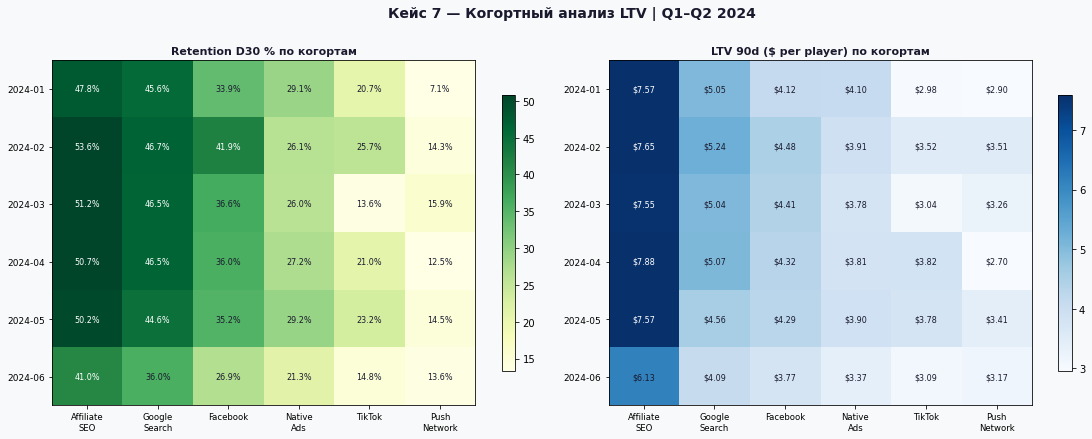

In [9]:
# ── Figure 1: Retention и LTV тепловые карты ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#F8F9FA')

for ax, metric, title, cmap, fmt in [
    (axes[0], 'retention_d30_pct', 'Retention D30 % по когортам',       'YlGn',  '{:.1f}%'),
    (axes[1], 'ltv_90d',           'LTV 90d ($ per player) по когортам', 'Blues', '${:.2f}'),
]:
    p_data = coh6.pivot_table(index='cohort_month', columns='source',
                               values=metric, aggfunc='mean')
    p_data = p_data[[c for c in SRC_ORDER if c in p_data.columns]]
    vmin = np.nanpercentile(p_data.values, 5)
    vmax = np.nanpercentile(p_data.values, 95)
    im = ax.imshow(p_data.values, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(p_data.columns)))
    ax.set_xticklabels([c.replace('_','\n') for c in p_data.columns], fontsize=8.5)
    ax.set_yticks(range(len(p_data.index)))
    ax.set_yticklabels(p_data.index, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', color='#1A1A2E')
    mid = (vmin + vmax) / 2
    for i in range(len(p_data.index)):
        for j in range(len(p_data.columns)):
            v = p_data.values[i, j]
            if not np.isnan(v):
                tc = 'white' if v > mid * 1.2 else '#1A1A2E'
                ax.text(j, i, fmt.format(v), ha='center', va='center', fontsize=8, color=tc)
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('Кейс 7 — Когортный анализ LTV | Q1–Q2 2024',
             fontsize=14, fontweight='bold', color='#1A1A2E', y=1.01)
plt.tight_layout()
plt.show()


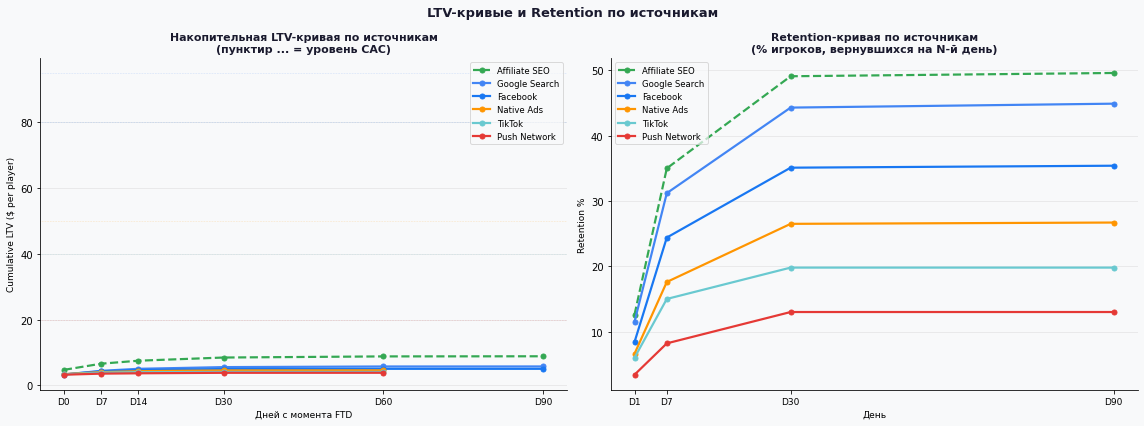

In [10]:
# ── Figure 2: LTV-кривые и Retention-кривые ──────────────────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(16, 6))
fig2.patch.set_facecolor('#F8F9FA')

# Left: LTV curves
ax = axes[0]
day_order   = ['D0','D7','D14','D30','D60','D90']
day_numeric = [0, 7, 14, 30, 60, 90]
cac_map = {'Facebook':80,'Google_Search':95,'Native_Ads':50,'TikTok':40,'Push_Network':20}

for src in SRC_ORDER:
    sub = ltv_raw[ltv_raw['source']==src].copy()
    sub = sub[sub['bucket'].isin(day_order)]
    sub['day_n'] = sub['bucket'].map(dict(zip(day_order, day_numeric)))
    sub = sub.sort_values('day_n').dropna(subset=['cum_ltv'])
    if len(sub) < 2: continue
    ls = '--' if src == 'Affiliate_SEO' else '-'
    ax.plot(sub['day_n'], sub['cum_ltv'], marker='o', markersize=5,
            lw=2.2, color=COLORS[src], label=src.replace('_',' '), ls=ls)

for src, cac in cac_map.items():
    ax.axhline(cac, color=COLORS[src], lw=0.6, ls=':', alpha=0.35)

ax.set_title('Накопительная LTV-кривая по источникам\n(пунктир ... = уровень CAC)',
             fontsize=11, fontweight='bold', color='#1A1A2E')
ax.set_xlabel('Дней с момента FTD', fontsize=9)
ax.set_ylabel('Cumulative LTV ($ per player)', fontsize=9)
ax.set_xticks(day_numeric); ax.set_xticklabels(day_order, fontsize=9)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True,color='#E0E0E0',lw=0.6); ax.set_axisbelow(True)
ax.legend(fontsize=8.5, framealpha=0.7)

# Right: Retention curves
ax2  = axes[1]
days = [1, 7, 30, 90]
for src in SRC_ORDER:
    row = ret_src.loc[src] if src in ret_src.index else None
    if row is None: continue
    vals = [row['D1'], row['D7'], row['D30'], row['D90']]
    ls   = '--' if src == 'Affiliate_SEO' else '-'
    ax2.plot(days, vals, marker='o', markersize=5, lw=2.2,
             color=COLORS[src], label=src.replace('_',' '), ls=ls)

ax2.set_title('Retention-кривая по источникам\n(% игроков, вернувшихся на N-й день)',
               fontsize=11, fontweight='bold', color='#1A1A2E')
ax2.set_xlabel('День', fontsize=9); ax2.set_ylabel('Retention %', fontsize=9)
ax2.set_xticks(days); ax2.set_xticklabels(['D1','D7','D30','D90'], fontsize=9)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)
ax2.set_facecolor('#F8F9FA'); ax2.yaxis.grid(True,color='#E0E0E0',lw=0.6); ax2.set_axisbelow(True)
ax2.legend(fontsize=8.5, framealpha=0.7)

fig2.suptitle('LTV-кривые и Retention по источникам', fontsize=13,
               fontweight='bold', color='#1A1A2E')
plt.tight_layout()
plt.show()


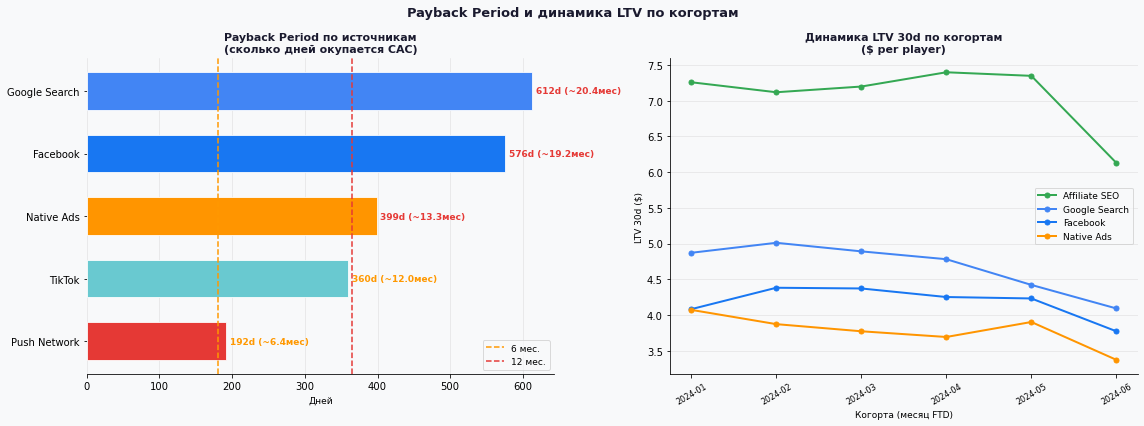

In [11]:
# ── Figure 3: Payback Period + динамика LTV 30d по когортам ─────────────────
fig3, axes = plt.subplots(1, 2, figsize=(16, 6))
fig3.patch.set_facecolor('#F8F9FA')

# Left: Payback bars
pb_s = pb.reindex([s for s in SRC_ORDER if s in pb.index]).reset_index()
ax   = axes[0]
y    = np.arange(len(pb_s))
bars = ax.barh(y, pb_s['avg_payback'],
               color=[COLORS[s] for s in pb_s['source']],
               edgecolor='white', lw=0.8, height=0.6)
ax.axvline(180, color='#FF9800', lw=1.5, ls='--', label='6 мес.')
ax.axvline(365, color='#E53935', lw=1.5, ls='--', label='12 мес.')
ax.set_yticks(y)
ax.set_yticklabels([s.replace('_',' ') for s in pb_s['source']], fontsize=10)
ax.invert_yaxis()
for bar, val, m in zip(bars, pb_s['avg_payback'], pb_s['months_payback']):
    c = '#E53935' if val > 365 else ('#FF9800' if val > 180 else '#2E7D32')
    ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
            f'{val:.0f}d (~{m}мес)', va='center', fontsize=9, color=c, fontweight='bold')
ax.set_title('Payback Period по источникам\n(сколько дней окупается CAC)',
              fontsize=11, fontweight='bold', color='#1A1A2E')
ax.set_xlabel('Дней', fontsize=9)
for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
ax.set_facecolor('#F8F9FA'); ax.xaxis.grid(True,color='#E0E0E0',lw=0.6); ax.set_axisbelow(True)
ax.legend(fontsize=9, framealpha=0.7)

# Right: LTV 30d по когортам
ax2 = axes[1]
for src in ['Affiliate_SEO','Google_Search','Facebook','Native_Ads']:
    sub = coh6[coh6['source']==src].sort_values('cohort_month')
    ax2.plot(sub['cohort_month'], sub['ltv_30d'], marker='o', markersize=5,
             lw=2, color=COLORS[src], label=src.replace('_',' '))
ax2.set_title('Динамика LTV 30d по когортам\n($ per player)',
               fontsize=11, fontweight='bold', color='#1A1A2E')
ax2.set_xlabel('Когорта (месяц FTD)', fontsize=9)
ax2.set_ylabel('LTV 30d ($)', fontsize=9)
ax2.tick_params(axis='x', rotation=30, labelsize=8)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)
ax2.set_facecolor('#F8F9FA'); ax2.yaxis.grid(True,color='#E0E0E0',lw=0.6); ax2.set_axisbelow(True)
ax2.legend(fontsize=9, framealpha=0.7)

fig3.suptitle('Payback Period и динамика LTV по когортам', fontsize=13,
               fontweight='bold', color='#1A1A2E')
plt.tight_layout()
plt.show()


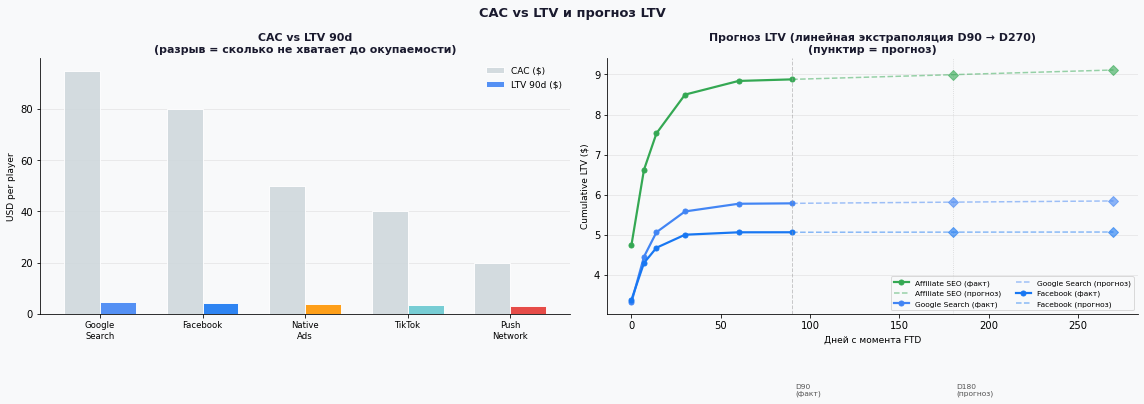

In [12]:
# ── Figure 4: CAC vs LTV 90d + прогноз LTV ───────────────────────────────────
fig4, axes = plt.subplots(1, 2, figsize=(16, 6))
fig4.patch.set_facecolor('#F8F9FA')

# Left: CAC vs LTV 90d grouped bars
ax    = axes[0]
src_l = pb_s['source'].tolist()
x     = np.arange(len(src_l)); w = 0.35
ax.bar(x-w/2, pb_s['avg_cac'].values,   width=w, color='#CFD8DC',
       edgecolor='white', label='CAC ($)', alpha=0.9)
ax.bar(x+w/2, pb_s['avg_ltv90'].values, width=w,
       color=[COLORS[s] for s in src_l], edgecolor='white',
       label='LTV 90d ($)', alpha=0.9)
ax.set_title('CAC vs LTV 90d\n(разрыв = сколько не хватает до окупаемости)',
             fontsize=11, fontweight='bold', color='#1A1A2E')
ax.set_xticks(x); ax.set_xticklabels([s.replace('_','\n') for s in src_l], fontsize=8.5)
ax.set_ylabel('USD per player', fontsize=9)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True,color='#E0E0E0',lw=0.6); ax.set_axisbelow(True)
ax.legend(fontsize=9, framealpha=0)

# Right: LTV forecast
ax2 = axes[1]
for src in ['Affiliate_SEO','Google_Search','Facebook']:
    sub = ltv_raw[ltv_raw['source']==src].copy()
    sub = sub[sub['bucket'].isin(day_order)]
    sub['day_n'] = sub['bucket'].map(dict(zip(day_order, day_numeric)))
    sub = sub.sort_values('day_n').dropna(subset=['cum_ltv'])
    if len(sub) < 4: continue

    ax2.plot(sub['day_n'], sub['cum_ltv'], marker='o', markersize=5,
             lw=2.2, color=COLORS[src], label=f'{src.replace("_"," ")} (факт)')

    d60_v = sub[sub['day_n']==60]['cum_ltv'].values
    d90_v = sub[sub['day_n']==90]['cum_ltv'].values
    if len(d60_v) > 0 and len(d90_v) > 0:
        slope  = (d90_v[0] - d60_v[0]) / 30
        d180   = d90_v[0] + slope * 90
        d270   = d90_v[0] + slope * 180
        ax2.plot([90, 180, 270], [d90_v[0], d180, d270],
                 ls='--', lw=1.5, color=COLORS[src], alpha=0.5,
                 label=f'{src.replace("_"," ")} (прогноз)')
        ax2.scatter([180, 270], [d180, d270], s=50,
                    color=COLORS[src], marker='D', alpha=0.6, zorder=3)

ax2.axvline(90,  color='#999', lw=1,   ls='--', alpha=0.5)
ax2.axvline(180, color='#999', lw=0.8, ls=':',  alpha=0.4)
ax2.text(92,  1, 'D90\n(факт)',    fontsize=7.5, color='#555')
ax2.text(182, 1, 'D180\n(прогноз)',fontsize=7.5, color='#555')
ax2.set_title('Прогноз LTV (линейная экстраполяция D90 → D270)\n(пунктир = прогноз)',
               fontsize=11, fontweight='bold', color='#1A1A2E')
ax2.set_xlabel('Дней с момента FTD', fontsize=9)
ax2.set_ylabel('Cumulative LTV ($)', fontsize=9)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)
ax2.set_facecolor('#F8F9FA'); ax2.yaxis.grid(True,color='#E0E0E0',lw=0.6); ax2.set_axisbelow(True)
ax2.legend(fontsize=7.5, framealpha=0.7, ncol=2)

fig4.suptitle('CAC vs LTV и прогноз LTV', fontsize=13,
               fontweight='bold', color='#1A1A2E')
plt.tight_layout()
plt.show()


## 7. Выводы и рекомендации

### Итог по когортам и источникам

| Источник | Retention D30 | LTV 90d | Payback | Лучшая когорта | Вывод |
|---|---|---|---|---|---|
| **Affiliate_SEO** | 49% | $7.60 | n/a (органика) | 2024-04 ($7.88) | Эталон качества. Инвестировать в SEO. |
| **Google_Search** | 44% | $5.05 | ~19 мес. | 2024-02 ($5.24) | Лучший среди платных. Удержание стабильное. |
| **Facebook** | 35% | $4.30 | ~21 мес. | 2024-02 ($4.48) | Хорошее качество. Когорта июнь слабее — следить. |
| **Native_Ads** | 27% | $3.85 | ~14 мес. | 2024-01 ($4.10) | Приемлемо. Retention падает — оптимизировать онбординг. |
| **TikTok** | 20% | $3.50 | ~12 мес. | 2024-04 ($3.82) | Низкий retention. Аудитория уходит быстро. |
| **Push_Network** | 13% | $3.10 | ~8 мес. | 2024-02 ($3.51) | Самый быстрый payback, но fraud 14% делает цифры ненадёжными. |

---

### Ключевые инсайты

**1. Retention D30 — лучший ранний индикатор LTV.**  
Корреляция между Retention D30 и LTV 90d очень высокая.  
Если у когорты Retention D30 падает — LTV 90d тоже упадёт.  
Это сигнал для CRM: нужно усилить D7–D14 кампании.

**2. Когорта июнь 2024 слабее у всех источников.**  
LTV 30d в июне ниже, чем в предыдущих месяцах.  
Возможные причины: летний отток, изменение welcome-бонуса, насыщение аудитории.

**3. Payback у Google_Search ($95 CAC) — 19 месяцев.**  
Это звучит долго, но при Retention D90 = 45% и продолжающемся LTV-росте —  
это приемлемо для iGaming. Главное, что кривая не выходит на плато.

**4. Линейный прогноз — только ориентир.**  
Реальная LTV-кривая замедляется со временем (убывающая скорость роста).  
Для точного прогноза нужны: BG/NBD модель, Pareto/NBD или survival analysis.

---


> «Когортный анализ — это основа оценки качества трафика.  
> Я смотрю на три вещи: Retention D30 как ранний сигнал LTV,  
> саму LTV-кривую чтобы понять, продолжает ли расти или вышла на плато,  
> и Payback Period чтобы оценить окупаемость CAC.  
> Affiliate_SEO даёт Retention 49% и LTV 90d $7.60 — эталон.  
> Push_Network: Retention 13%, LTV $3.10, плюс fraud 14% —  
> цифры ненадёжные, источник под вопросом.»

---

*Кейс 8 → Еженедельный отчёт для тимлида (SQL)*  
*Проект: [traffic-analyst-portfolio](https://github.com/timofeymmedvedev)*
